In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

## TASK 1

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## TASK 2

In [ ]:
print(df.isnull().sum())
df = df.dropna()
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print("\nDataFrame info after cleaning and date conversion:")
df.info()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

DataFrame info after cleaning and date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9

## Task 3

In [ ]:
# Extract Month & Year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

### Monthly Sales Trend

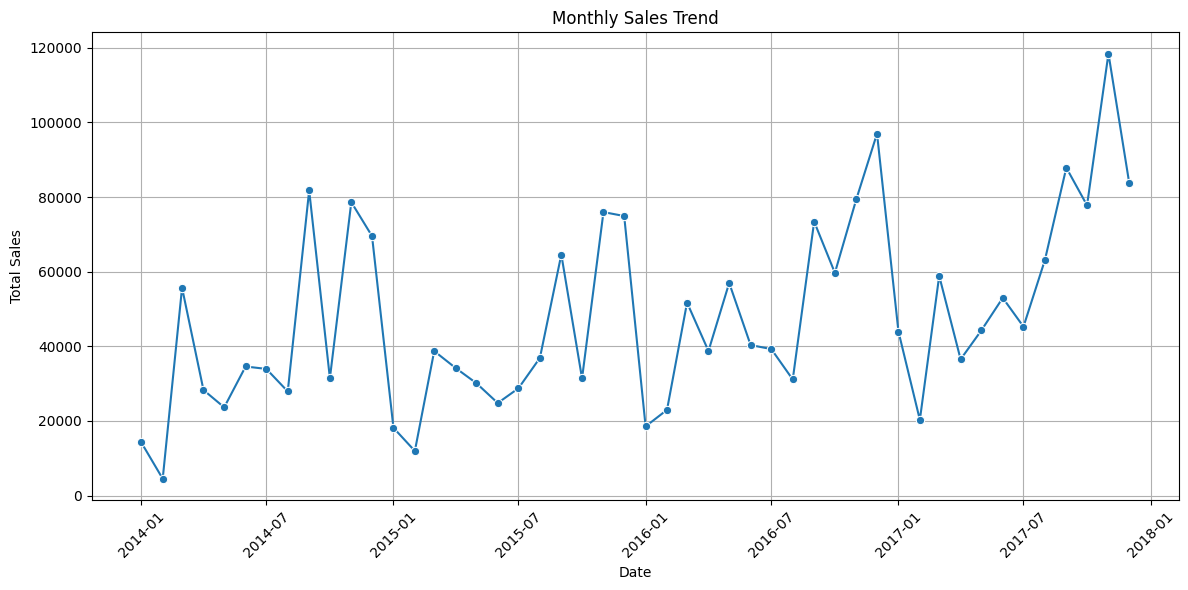

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str))

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Sales', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Yearly Sales Trend

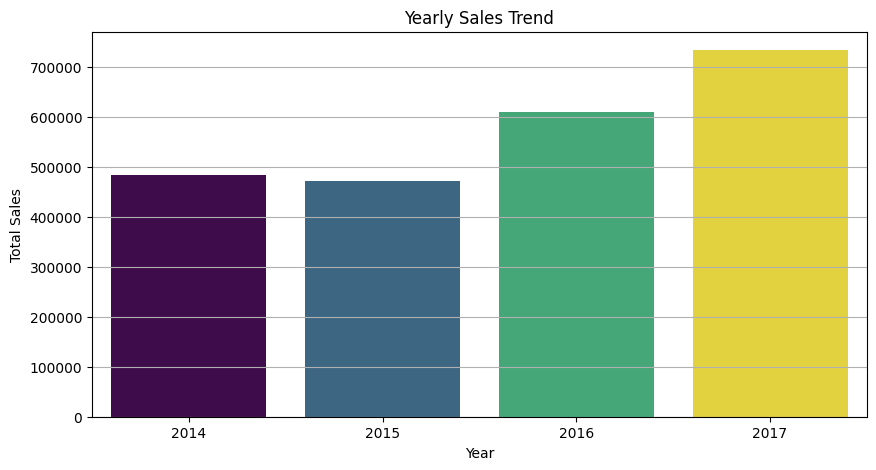

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Year', y='Sales', data=yearly_sales, palette='viridis', hue='Year', legend=False)
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(axis='y')
plt.show()

In [ ]:
# Calculate 'Net Sales' after discount
df['Net Sales'] = df['Sales'] * (1 - df['Discount'])

# Calculate 'Profit Margin'
df['Profit Margin'] = df['Profit'] / df['Sales']

# Display the first few rows with the new columns
display(df[['Sales', 'Discount', 'Net Sales', 'Profit', 'Profit Margin']].head())

,Sales,Discount,Net Sales,Profit,Profit Margin
0,261.9600,0.00,261.960000,41.9136,0.1600
1,731.9400,0.00,731.940000,219.5820,0.3000
2,14.6200,0.00,14.620000,6.8714,0.4700
3,957.5775,0.45,526.667625,-383.0310,-0.4000
4,22.3680,0.20,17.894400,2.5164,0.1125


In [ ]:
print('Verifying Net Sales and Profit Margin calculations for sample rows:')

sample_df = df[['Sales', 'Discount', 'Profit', 'Net Sales', 'Profit Margin']].head()
display(sample_df)

# Manual recalculation for verification
sample_df['Calculated Net Sales'] = sample_df['Sales'] * (1 - sample_df['Discount'])
sample_df['Calculated Profit Margin'] = sample_df['Profit'] / sample_df['Sales']

print('\nComparison of calculated vs. stored values:')
display(sample_df[['Sales', 'Discount', 'Profit', 'Net Sales', 'Calculated Net Sales', 'Profit Margin', 'Calculated Profit Margin']])

# Check for equality (allowing for floating point precision differences)
print('\nAre Net Sales calculations matching?')
print(np.isclose(sample_df['Net Sales'], sample_df['Calculated Net Sales']).all())

print('\nAre Profit Margin calculations matching?')
print(np.isclose(sample_df['Profit Margin'], sample_df['Calculated Profit Margin']).all())

Verifying Net Sales and Profit Margin calculations for sample rows:


,Sales,Discount,Profit,Net Sales,Profit Margin
0,261.9600,0.00,41.9136,261.960000,0.1600
1,731.9400,0.00,219.5820,731.940000,0.3000
2,14.6200,0.00,6.8714,14.620000,0.4700
3,957.5775,0.45,-383.0310,526.667625,-0.4000
4,22.3680,0.20,2.5164,17.894400,0.1125



Comparison of calculated vs. stored values:


,Sales,Discount,Profit,Net Sales,Calculated Net Sales,Profit Margin,Calculated Profit Margin
0,261.9600,0.00,41.9136,261.960000,261.960000,0.1600,0.1600
1,731.9400,0.00,219.5820,731.940000,731.940000,0.3000,0.3000
2,14.6200,0.00,6.8714,14.620000,14.620000,0.4700,0.4700
3,957.5775,0.45,-383.0310,526.667625,526.667625,-0.4000,-0.4000
4,22.3680,0.20,2.5164,17.894400,17.894400,0.1125,0.1125



Are Net Sales calculations matching?
True

Are Profit Margin calculations matching?
True


## TASK 4


In [ ]:
# Calculate total sales by category
sales_category = df.groupby('Category')['Sales'].sum()
print(sales_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [20]:
# Calculate total profit by region
profit_region = df.groupby('Region')['Profit'].sum()
print(profit_region)


Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [21]:
# Identify top 5 customers based on sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


In [22]:
# Analyze sales trends over time (monthly)
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
print(monthly_sales)


Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

## TASK 5

In [23]:
# Sales by Category & Region
pivot1 = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')
print(pivot1)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


In [24]:
# Sales trend by Segment over time
pivot2 = pd.pivot_table(df, values='Sales', index='Month', columns='Segment', aggfunc='sum')
print(pivot2)

Segment     Consumer    Corporate  Home Office
Month                                         
1         50441.2906   26790.3480   17693.1970
2         33826.1760   14575.0670   11350.0084
3         89174.7070   58239.9132   57590.8686
4         54845.1895   49233.1636   33683.7755
5         86932.7144   47289.0323   20807.0650
6         82910.1803   40858.5370   28949.9620
7         81769.7730   46919.2060   18549.1180
8         82319.8063   57529.4477   19194.8090
9        185055.9196   74020.2213   48573.8048
10        66713.0877   78291.7600   55318.1370
11       170958.7383  119431.3957   62070.9370
12       176453.7623   92968.2750   55871.4662


In [25]:
# Profit by Sub-Category
pivot3 = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')
print(pivot3)

                  Profit
Sub-Category            
Accessories   41936.6357
Appliances    18138.0054
Art            6527.7870
Binders       30221.7633
Bookcases     -3472.5560
Chairs        26590.1663
Copiers       55617.8249
Envelopes      6964.1767
Fasteners       949.5182
Furnishings   13059.1436
Labels         5546.2540
Machines       3384.7569
Paper         34053.5693
Phones        44515.7306
Storage       21278.8264
Supplies      -1189.0995
Tables       -17725.4811


## TASK 6


In [29]:
# Split the dataset into at least two meaningful DataFrames

# Create a DataFrame for unique customer information
df_customers = df[['Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region']].drop_duplicates(subset='Customer ID').reset_index(drop=True)

# Create a DataFrame for unique product information
df_products = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']].drop_duplicates(subset='Product ID').reset_index(drop=True)

# Create a DataFrame for order details, including foreign keys to link to customers and products
df_orders = df[['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Net Sales', 'Profit Margin', 'Month', 'Year']]


In [31]:
# Merge back
# First, merge df_customers with df_orders on 'Customer ID'
merged_df = pd.merge(df_customers, df_orders, on='Customer ID', how='left')

# Then, merge the result with df_products on 'Product ID'
merged_df = pd.merge(merged_df, df_products, on='Product ID', how='left')

In [32]:
# Verify
merged_df.head()

,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Row ID,Order ID,...,Quantity,Discount,Profit,Net Sales,Profit Margin,Month,Year,Category,Sub-Category,Product Name
0,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,1,CA-2016-152156,...,2,0.0,41.9136,261.9600,0.160,11,2016,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,2,CA-2016-152156,...,3,0.0,219.5820,731.9400,0.300,11,2016,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,5492,CA-2017-164098,...,2,0.2,1.8160,14.5280,0.100,1,2017,Office Supplies,Storage,"SimpliFile Personal File, Black Granite, 15w x..."
3,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,6878,US-2015-123918,...,6,0.6,-95.2476,52.5504,-0.725,10,2015,Furniture,Furnishings,C-Line Cubicle Keepers Polyproplyene Holder w/...
4,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,6879,US-2015-123918,...,1,0.2,1.8704,4.2752,0.350,10,2015,Office Supplies,Paper,Xerox 1986


## TASK 7

In [33]:
import matplotlib.pyplot as plt

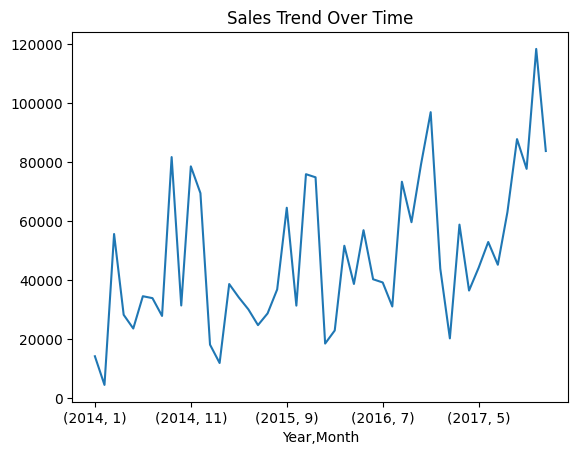

In [34]:
# Line chart for sales trend over time
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

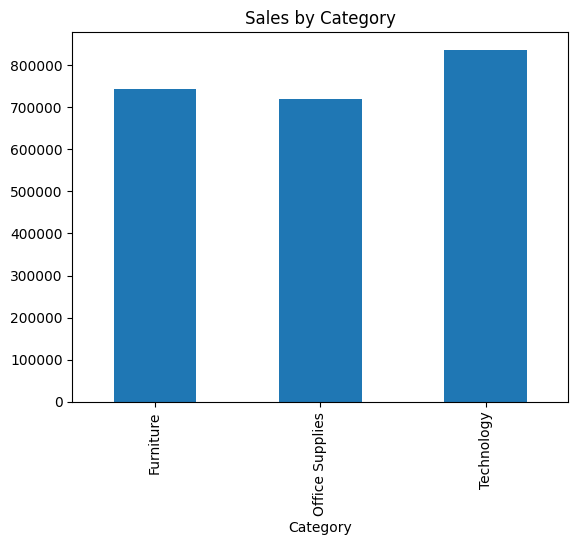

In [35]:
# Bar chart for sales by category
sales_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

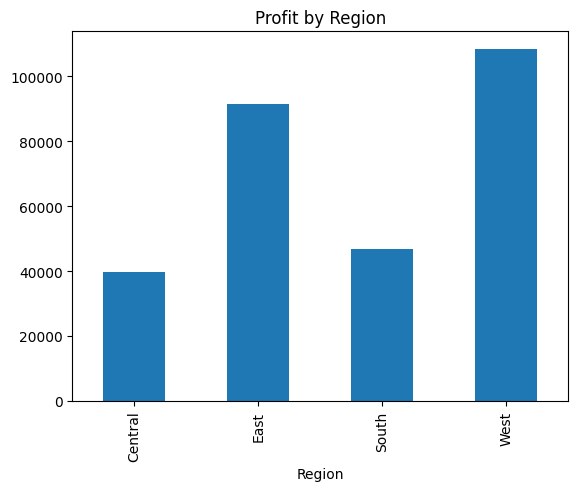

In [36]:
# Bar chart for profit by region
profit_region.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

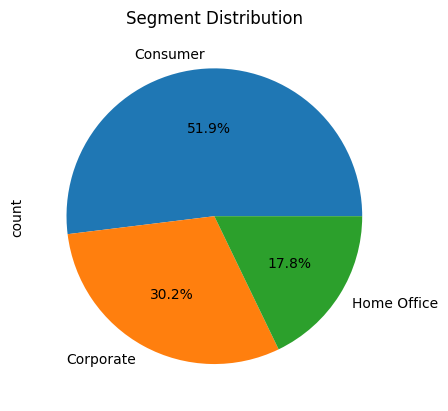

In [37]:
# Pie chart for segment distribution
segment = df['Segment'].value_counts()

segment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.show()

# TASK 8

In [38]:
# The most profitable category
df.groupby('Category')['Profit'].sum().idxmax()

'Technology'

In [39]:
# The least performing region
df.groupby('Region')['Profit'].sum().idxmin()

'Central'

## patterns between sales and profit
- High sales ≠ high profit always
- Some categories have high sales but low margins

## trends over time
- Sales increase during certain months (seasonality)
- Growth trend over years

